# 05 — MODIS flood labels on the GloFAS grid

Turns the daily MCDWD_L3 tiles downloaded by `download_mcdwd_curl.sh` into a label cube that
sits on **exactly** the grid produced by `01_download_process.ipynb`, so labels and inputs can be
stacked without any further alignment.

Per day: mosaic `h25v06` + `h26v06` -> keep pixels inside the ROI -> aggregate the 250 m
classes into each 0.05 deg cell -> stack 123 days.

**Aggregation is by fraction, not by mode.** Each 0.05 deg cell holds ~380 valid MODIS pixels, so
`flood_fraction` (share of valid pixels classed as flood) carries far more signal than a single
winning class. `flood_binary` is that fraction thresholded, for when a hard label is needed.

**No-data (255) is never counted as dry.** It is excluded from both numerator and denominator, and
what is left is reported as `valid_fraction`. Cells below `MIN_VALID` become NaN.

In [1]:
# ============================================================
# CELL 1 - Configuration
# ============================================================
from pathlib import Path
from datetime import date, timedelta
import glob, json, time

import numpy as np
import xarray as xr
from pyhdf.SD import SD, SDC

# --- window (matches notebook 01) ---
YEAR, START_DOY, END_DOY = 2022, 121, 243        # 2022-05-01 .. 2022-08-31

# --- tiles: h25 + h26 together cover the ROI; h27 lies entirely east of it ---
TILES = {"h25v06": (25, 6), "h26v06": (26, 6)}

# --- label definition -------------------------------------------------------
# MCDWD classes: 0 no water | 1 reference (permanent) water | 2 recurring flood |
#                3 flood    | 255 no observation (cloud/gap)
LAYER          = "Flood_1Day_250m"   # daily, matches the GloFAS daily step
GAPFILL_LAYER  = "Flood_3Day_250m"   # fills pixel-level 255 from the 3-day composite; None = off
FLOOD_CLASSES  = (2, 3)              # inundation beyond permanent water; use (3,) for flood only
FRAC_THRESH    = 0.50                # flood_fraction >= this -> flood_binary = 1
MIN_VALID      = 0.20                # cell needs this share of valid pixels, else NaN

# --- paths ---
from paths import MODIS_HDF, GLOFAS_READY, FLOOD_LABELS as OUT_DIR

HDF_DIR   = MODIS_HDF / str(YEAR)
GLOFAS_NC = sorted(GLOFAS_READY.glob("*_norm.nc"))[0]

# netCDF4 in this env is built against numpy 1.x and fails to import, so use h5netcdf.
NC_ENGINE = "h5netcdf"

# --- target grid: read from the GloFAS cube so the two can never drift apart ---
_g   = xr.open_dataset(GLOFAS_NC, engine=NC_ENGINE)
LAT  = _g.latitude.values          # descending
LON  = _g.longitude.values         # ascending
TIME = _g.time.values
NLAT, NLON = LAT.size, LON.size
D        = float(abs(LAT[1] - LAT[0]))
LAT_TOP  = float(LAT[0]  + D / 2);  LAT_BOT   = float(LAT[-1] - D / 2)
LON_LEFT = float(LON[0]  - D / 2);  LON_RIGHT = float(LON[-1] + D / 2)
_g.close()

print(f"target grid : {NLAT} x {NLON} @ {D} deg")
print(f"             lat {LAT_BOT} .. {LAT_TOP} | lon {LON_LEFT} .. {LON_RIGHT}")
print(f"window      : {TIME[0]} .. {TIME[-1]} ({TIME.size} days)")
print(f"label       : {LAYER}, classes {FLOOD_CLASSES}, gapfill={GAPFILL_LAYER}")

/opt/anaconda3/envs/sia/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.dylib'.
dlopen(libgmt.dylib, 0x0006): tried: 'libgmt.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibgmt.dylib' (no such file), '/opt/anaconda3/envs/sia/lib/python3.11/lib-dynload/../../libgmt.dylib' (no such file), '/opt/anaconda3/envs/sia/bin/../lib/libgmt.dylib' (no such file), '/usr/lib/libgmt.dylib' (no such file, not in dyld cache), 'libgmt.dylib' (no such file), '/usr/local/lib/libgmt.dylib' (no such file), '/usr/lib/libgmt.dylib' (no such file, not in dyld cache)
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


target grid : 130 x 140 @ 0.05000000000000071 deg
             lat 21.0 .. 27.5 | lon 87.0 .. 94.0
window      : 2022-05-01T00:00:00.000000000 .. 2022-08-31T00:00:00.000000000 (123 days)
label       : Flood_1Day_250m, classes (2, 3), gapfill=Flood_3Day_250m


## 1 — Pixel-to-cell map

MODIS sinusoidal: `x = R*lon*cos(lat)`, `y = R*lat`. Latitude depends only on the row, longitude on
both, which is why the tiles are trapezoids that lean east as latitude rises — and why `h25v06` is
needed for the north-west of the box even though `h26v06` looks like it should cover everything.

The map depends only on the tile, not on the day, so it is built once and reused for all 123 days.

In [2]:
# ============================================================
# CELL 2 - Build the pixel -> cell map once per tile
# ============================================================
R       = 6371007.181                 # MODIS sphere radius [m]
T_SIZE  = np.radians(10.0) * R        # one 10-degree tile [m]
PIX     = T_SIZE / 4800               # 250 m nominal

def tile_map(h, v):
    """Row, col and flat target-cell index for each 250 m pixel of tile (h,v) inside the ROI."""
    x_ul = (h - 18) * T_SIZE + 0.5 * PIX
    y_ul = (9  - v) * T_SIZE - 0.5 * PIX

    lat  = np.degrees((y_ul - np.arange(4800) * PIX) / R)
    rsel = np.where((lat < LAT_TOP) & (lat >= LAT_BOT))[0]         # rows overlapping the ROI
    if rsel.size == 0:
        return None
    lat_s = lat[rsel]

    x   = x_ul + np.arange(4800) * PIX
    lon = np.degrees(x[None, :] / (R * np.cos(np.radians(lat_s))[:, None]))
    ok  = (lon >= LON_LEFT) & (lon < LON_RIGHT)
    rr, cc = np.nonzero(ok)

    iy = np.clip(((LAT_TOP - lat_s[rr]) / D).astype(np.int32), 0, NLAT - 1)
    ix = np.clip(((lon[rr, cc] - LON_LEFT) / D).astype(np.int32), 0, NLON - 1)
    return rsel[rr].astype(np.int32), cc.astype(np.int32), (iy * NLON + ix).astype(np.int32)

MAPS = {t: tile_map(*hv) for t, hv in TILES.items()}
MAPS = {t: m for t, m in MAPS.items() if m is not None}

covered = np.zeros(NLAT * NLON, bool)
for t, m in MAPS.items():
    hit = np.unique(m[2])
    covered[hit] = True
    print(f"{t}: {m[2].size:>9,} pixels in ROI -> {hit.size:>6,}/{NLAT*NLON} cells")
print(f"combined: {covered.sum():,}/{NLAT*NLON} cells covered")
assert covered.all(), "tiles do not cover the whole ROI - add the missing tile to TILES"

h25v06: 1,383,023 pixels in ROI ->  2,747/18200 cells
h26v06: 8,170,028 pixels in ROI -> 15,597/18200 cells
combined: 18,200/18200 cells covered


## 2 — Build the cube

For every day and tile: read the layer, optionally patch pixel-level no-data from the 3-day
composite, then two `bincount` passes per cell — flood pixels and valid pixels. The fraction is
their ratio, so tile overlap is handled correctly (both tiles contribute to the same sums).

In [3]:
# ============================================================
# CELL 3 - Stack all days
# ============================================================
NCELL   = NLAT * NLON
FLOODSET = np.array(FLOOD_CLASSES, dtype=np.uint8)

def read_day(doy):
    """Flood-pixel and valid-pixel counts per target cell for one day."""
    num = np.zeros(NCELL); den = np.zeros(NCELL)
    for t, (rr, cc, idx) in MAPS.items():
        hits = glob.glob(str(HDF_DIR / f"MCDWD_L3.A{YEAR}{doy:03d}.{t}.*.hdf"))
        if not hits:
            raise FileNotFoundError(f"no {t} file for {YEAR} DOY {doy:03d}")
        hdf = SD(hits[0], SDC.READ)
        a   = hdf.select(LAYER)[:]
        if GAPFILL_LAYER:                      # patch cloud gaps from the longer composite
            gap = a == 255
            if gap.any():
                a = a.copy()
                a[gap] = hdf.select(GAPFILL_LAYER)[:][gap]
        v     = a[rr, cc]
        valid = v != 255
        num  += np.bincount(idx[valid], weights=np.isin(v[valid], FLOODSET), minlength=NCELL)
        den  += np.bincount(idx[valid], minlength=NCELL)
    return num, den

doys   = list(range(START_DOY, END_DOY + 1))
assert len(doys) == TIME.size, f"{len(doys)} days vs {TIME.size} GloFAS time steps"

frac  = np.full((len(doys), NCELL), np.nan, np.float32)
vfrac = np.zeros((len(doys), NCELL), np.float32)

# pixels per cell, from the map alone - the denominator for valid_fraction
per_cell = np.zeros(NCELL)
for _, _, idx in MAPS.values():
    per_cell += np.bincount(idx, minlength=NCELL)

t0 = time.time()
for i, doy in enumerate(doys):
    num, den = read_day(doy)
    vf = den / np.maximum(per_cell, 1)
    good = vf >= MIN_VALID
    frac[i, good] = (num[good] / den[good]).astype(np.float32)
    vfrac[i] = vf
    if (i + 1) % 20 == 0 or i == len(doys) - 1:
        print(f"  {i+1:>3}/{len(doys)} days  ({time.time()-t0:5.1f}s)")

frac  = frac.reshape(len(doys), NLAT, NLON)
vfrac = vfrac.reshape(len(doys), NLAT, NLON)
binary = np.where(np.isnan(frac), -1, (frac >= FRAC_THRESH).astype(np.int8)).astype(np.int8)

print(f"\ndone in {time.time()-t0:.1f}s")
print(f"cells with a usable observation : {np.isfinite(frac).mean()*100:.1f}% of all day-cells")
print(f"mean valid_fraction             : {vfrac.mean():.3f}")
print(f"flooded (binary==1)             : {(binary==1).sum():,} day-cells")

   20/123 days  (  6.3s)
   40/123 days  ( 12.5s)
   60/123 days  ( 17.7s)
   80/123 days  ( 23.0s)
  100/123 days  ( 27.5s)
  120/123 days  ( 32.7s)
  123/123 days  ( 33.5s)

done in 33.5s
cells with a usable observation : 42.0% of all day-cells
mean valid_fraction             : 0.317
flooded (binary==1)             : 2,767 day-cells


In [4]:
# ============================================================
# CELL 4 - Save
# ============================================================
ds = xr.Dataset(
    {
        "flood_fraction": (("time", "latitude", "longitude"), frac,
                           {"long_name": "flooded share of valid MODIS pixels in the cell",
                            "classes_counted_as_flood": str(FLOOD_CLASSES), "units": "1"}),
        "flood_binary":   (("time", "latitude", "longitude"), binary,
                           {"long_name": f"flood_fraction >= {FRAC_THRESH}",
                            "flag_values": "-1 no data, 0 not flooded, 1 flooded"}),
        "valid_fraction": (("time", "latitude", "longitude"), vfrac,
                           {"long_name": "share of the cell's MODIS pixels with a valid observation",
                            "units": "1"}),
    },
    coords={"time": TIME, "latitude": LAT, "longitude": LON},
    attrs={
        "title": "MODIS MCDWD flood labels regridded to the GloFAS 0.05 deg grid",
        "source_product": "MCDWD_L3 v061 (NASA LAADS DAAC)",
        "source_layer": LAYER, "gapfill_layer": str(GAPFILL_LAYER),
        "tiles": " ".join(MAPS), "grid_from": GLOFAS_NC.name,
        "flood_classes": str(FLOOD_CLASSES), "frac_threshold": FRAC_THRESH,
        "min_valid_fraction": MIN_VALID,
        "note": "255 (no observation) is excluded from both numerator and denominator; "
                "it is never treated as dry.",
    },
)

tag  = f"bd_ne_india_{str(TIME[0])[:10]}_to_{str(TIME[-1])[:10]}"
nc   = OUT_DIR / f"flood_labels_{tag}.nc"
ds.to_netcdf(nc, engine=NC_ENGINE)

man = {
    "tag": tag, "product": "MCDWD_L3 v061", "layer": LAYER, "gapfill_layer": GAPFILL_LAYER,
    "tiles": list(MAPS), "flood_classes": list(FLOOD_CLASSES),
    "frac_threshold": FRAC_THRESH, "min_valid_fraction": MIN_VALID,
    "shape_time_lat_lon": list(frac.shape), "resolution_deg": D,
    "grid_source": GLOFAS_NC.name,
    "usable_day_cell_fraction": float(np.isfinite(frac).mean()),
    "files": {"labels": nc.name},
}
(OUT_DIR / f"flood_labels_{tag}_manifest.json").write_text(json.dumps(man, indent=2))
print(f"wrote {nc}  ({nc.stat().st_size/1e6:.1f} MB)")
print(ds)

wrote /Users/sapu/Desktop/Research/Climate/flood_map/data/interim/flood_labels/flood_labels_bd_ne_india_2022-05-01_to_2022-08-31.nc  (20.2 MB)
<xarray.Dataset> Size: 20MB
Dimensions:         (time: 123, latitude: 130, longitude: 140)
Coordinates:
  * time            (time) datetime64[ns] 984B 2022-05-01 ... 2022-08-31
  * latitude        (latitude) float64 1kB 27.48 27.43 27.38 ... 21.07 21.02
  * longitude       (longitude) float64 1kB 87.03 87.08 87.12 ... 93.92 93.97
Data variables:
    flood_fraction  (time, latitude, longitude) float32 9MB 0.0 0.0 ... 0.0 0.0
    flood_binary    (time, latitude, longitude) int8 2MB 0 0 0 0 0 ... 0 0 0 0 0
    valid_fraction  (time, latitude, longitude) float32 9MB 1.0 1.0 ... 1.0 1.0
Attributes:
    title:               MODIS MCDWD flood labels regridded to the GloFAS 0.0...
    source_product:      MCDWD_L3 v061 (NASA LAADS DAAC)
    source_layer:        Flood_1Day_250m
    gapfill_layer:       Flood_3Day_250m
    tiles:               h25v06 h26v

## 3 — Look at it before trusting it

Two checks. The flooded-area curve should rise through the monsoon and spike in the second half of
June 2022 (the Sylhet flood). The `valid_fraction` curve is the honest companion: monsoon cloud is
heaviest exactly when the flood is, so a dip in coverage next to a spike in flooded area is the
thing to be suspicious of.

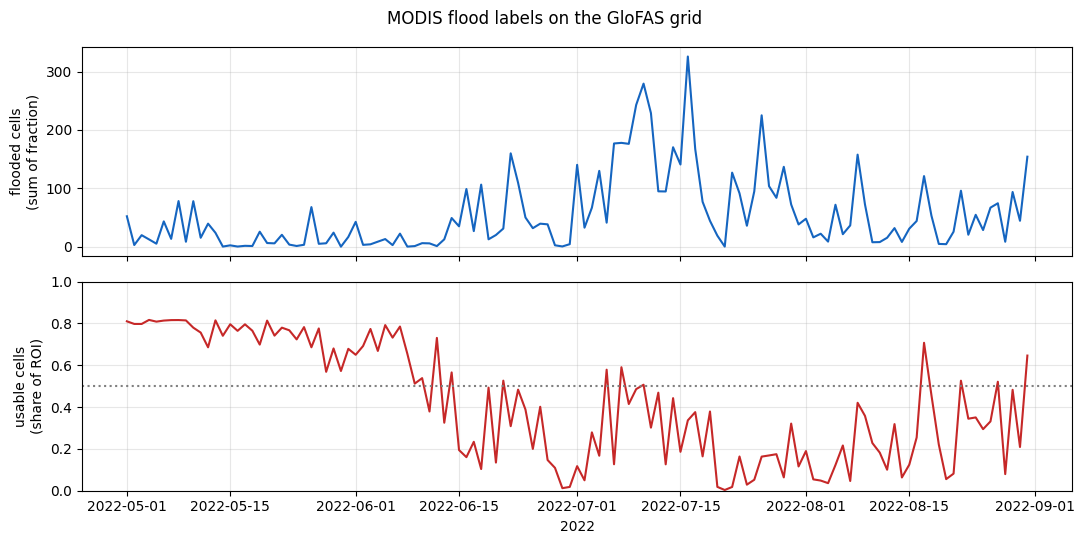

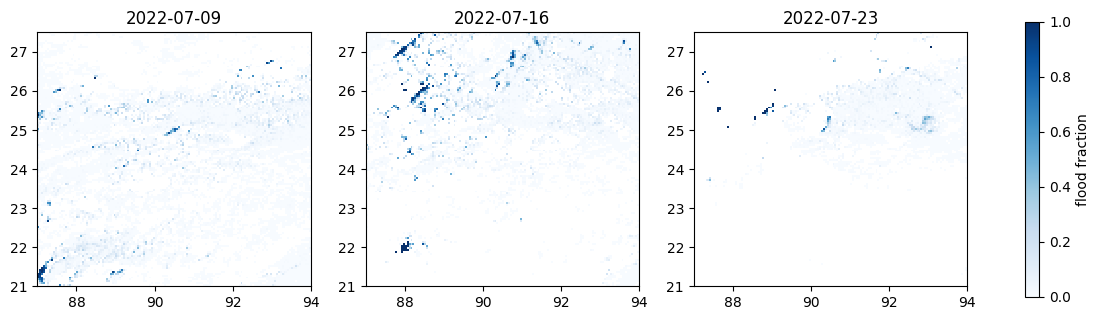

peak flooded day: 2022-07-16


In [5]:
# ============================================================
# CELL 5 - Quick look
# ============================================================
import matplotlib.pyplot as plt

area = np.nansum(np.where(np.isfinite(frac), frac, 0), axis=(1, 2))
cov  = np.isfinite(frac).mean(axis=(1, 2))

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].plot(TIME, area, color="#1565c0")
ax[0].set_ylabel("flooded cells\n(sum of fraction)")
ax[0].grid(alpha=.3)
ax[1].plot(TIME, cov, color="#c62828")
ax[1].axhline(0.5, ls=":", c="grey")
ax[1].set_ylabel("usable cells\n(share of ROI)"); ax[1].set_ylim(0, 1); ax[1].grid(alpha=.3)
ax[1].set_xlabel("2022")
fig.suptitle("MODIS flood labels on the GloFAS grid", y=.98)
fig.tight_layout(); plt.show()

# peak-flood day and the two around it
pk = int(np.nanargmax(area))
sel = [max(pk - 7, 0), pk, min(pk + 7, len(doys) - 1)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for a, i in zip(axes, sel):
    im = a.pcolormesh(LON, LAT, frac[i], vmin=0, vmax=1, cmap="Blues", shading="nearest")
    a.set_title(str(TIME[i])[:10]); a.set_aspect("equal")
fig.colorbar(im, ax=axes, label="flood fraction", shrink=.85)
plt.show()
print(f"peak flooded day: {str(TIME[pk])[:10]}")